# 🤖 06 — Entrenamiento: `brake_hydro`
## Silver · Turbina Kelmarsh T1 · 2018–2022

---

### Contexto

Este notebook entrena el modelo LightGBM para la familia **`brake_hydro`** (lead time 120h). Carga las features generadas en `05_features.ipynb`, aplica un split temporal 80/20, entrena con early stopping, y evalúa tanto por fila como por evento.

### Nota sobre esta familia

Con 58 eventos (el conjunto más pequeño), se usa mayor regularización: `num_leaves=31` y `min_child_samples=30` para evitar overfitting. **Limitación documentada**: de los 3 fallos en el período de test, 2 son fallos en cascada (provocados por el convertidor de frecuencia y por sobrecalentamiento del generador) y 1 es una rotura abrupta de presión hidráulica. Ninguno de los tres corresponde a degradación gradual del sistema hidráulico, por lo que no son predecibles con los sensores SCADA disponibles. El Event Recall de 0.33 en test es el techo físico para este conjunto de fallos.

### Evaluación por evento

Además de las métricas clásicas (Precision, Recall, F1 por fila), se calcula el **Event Recall**: de los N fallos reales en el período de test, ¿cuántos tuvieron al menos una alerta en las horas previas? Esta es la métrica operativamente relevante para un sistema de mantenimiento predictivo.

### Split temporal

Se usa un split **temporal** (no aleatorio): los primeros 80% del tiempo para train, los últimos 20% para test. Un split aleatorio introduciría data leakage temporal (el modelo vería en train datos del futuro respecto al test).

| Período | Fechas aproximadas |
|---------|-------------------|
| Train | 2018-01 → 2022-02 |
| Test  | 2022-02 → 2022-12 |

## 1. Imports y Configuración

In [9]:
import os, json, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score
)
warnings.filterwarnings('ignore')

base_dir   = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, 'data', 'silver')
models_dir = os.path.join(base_dir, 'data', 'models')
images_dir = os.path.join(base_dir, 'docs', 'images')
os.makedirs(models_dir, exist_ok=True)

LGBM_PARAMS = {
    'n_estimators':     1000,   # early stopping determina el número real usado
    'class_weight':     'balanced',  # compensa el desequilibrio de clases automáticamente
    'learning_rate':    0.05,
    'num_leaves':       31,   # reducido: dataset pequeño, más regularización
    'min_child_samples':30,   # mínimo de muestras por hoja
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}

FAULT_FAMILIES = {
    'brake_hydro': {'lead_hours': 120, 'color': '#BA7517'},
}

print('Configuración cargada')
print(f'  Familia: brake_hydro')
print(f'  Lead time: 120h')


Configuración cargada
  Familia: brake_hydro
  Lead time: 120h


## 2. Funciones de Evaluación y Entrenamiento

In [10]:
def evaluate_by_event(test_df, y_prob, family, threshold, lead_hours):
    # Para cada fallo real en test, comprueba si hubo al menos una alerta
    # (prob >= threshold) en las lead_hours horas previas al inicio de la
    # ventana pre-fallo. Esta es la métrica operativamente relevante:
    # en producción lo que importa es si el equipo de mantenimiento recibio
    # una alerta antes del fallo, no cuántas filas individuales se clasificaron bien.
    df_e = test_df[['timestamp']].copy()
    df_e['prob']   = y_prob
    df_e['is_pre'] = test_df[f'is_pre_{family}'].values
    df_e = df_e.sort_values('timestamp').reset_index(drop=True)

    # Detectar inicio de cada ventana pre-fallo (transición False → True)
    is_pre = df_e['is_pre'].astype(bool)
    fault_starts = df_e['timestamp'][is_pre & ~is_pre.shift(1, fill_value=False)].tolist()

    detected, details = 0, []
    for fs in fault_starts:
        mask     = (df_e['timestamp'] >= fs) & (df_e['timestamp'] < fs + pd.Timedelta(hours=lead_hours))
        max_prob = df_e.loc[mask, 'prob'].max() if mask.any() else 0.0
        hit      = bool(max_prob >= threshold)
        if hit: detected += 1
        details.append({'fault_start': fs, 'max_prob': round(float(max_prob), 3), 'detected': hit})

    total = len(fault_starts)
    return {
        'event_recall': round(detected / total, 4) if total > 0 else 0.0,
        'events_detected': detected,
        'events_total': total,
        'details': details,
    }


def train_model(family, params, train_ratio=0.80):
    cfg        = FAULT_FAMILIES[family]
    target_col = f'is_pre_{family}'
    hours_col  = f'hours_to_{family}'

    df = pd.read_parquet(os.path.join(silver_dir, f'features_{family}.parquet'))
    df = df.dropna(subset=[target_col]).sort_values('timestamp').reset_index(drop=True)
    feature_cols = [c for c in df.columns if c not in ['timestamp', target_col, hours_col]]

    cutoff = df['timestamp'].quantile(train_ratio)
    train  = df[df['timestamp'] <  cutoff].copy()
    test   = df[df['timestamp'] >= cutoff].copy()

    X_train, y_train = train[feature_cols].fillna(0), train[target_col].astype(int)
    X_test,  y_test  = test[feature_cols].fillna(0),  test[target_col].astype(int)

    print(f'Corte temporal: {cutoff.date()}')
    print(f'Train: {len(train):,} filas  |  {y_train.sum():,} positivos ({100*y_train.mean():.1f}%)')
    print(f'Test:  {len(test):,} filas  |  {y_test.sum():,} positivos ({100*y_test.mean():.1f}%)')
    print(f'Features: {len(feature_cols)}')

    t0    = time.time()
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(200),
        ],
    )
    y_prob = model.predict_proba(X_test)[:, 1]

    # Threshold: el menor valor que mantiene precision_row >= 10%
    # Se prioriza Recall (detectar fallos) sobre Precision (pocas falsas alarmas).
    # Un umbral demasiado bajo generaria alertas constantes; 10% es el mínimo aceptable.
    prec_c, rec_c, thr_c = precision_recall_curve(y_test, y_prob)
    valid = [(t, r) for p, r, t in zip(prec_c, rec_c, thr_c) if p >= 0.10]
    threshold = min(valid, key=lambda x: -x[1])[0] if valid else 0.20

    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    rep    = classification_report(y_test, y_pred,
                                   target_names=['Normal', 'Pre-fallo'],
                                   output_dict=True)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = float('nan')

    ev = evaluate_by_event(test, y_prob, family, threshold, cfg['lead_hours'])

    metrics = {
        'family':          family,
        'threshold':       round(float(threshold), 3),
        'lead_hours':      cfg['lead_hours'],
        'auc_roc':         round(auc, 4),
        'precision_row':   round(rep['Pre-fallo']['precision'], 4),
        'recall_row':      round(rep['Pre-fallo']['recall'],    4),
        'f1_row':          round(rep['Pre-fallo']['f1-score'],  4),
        'event_recall':    ev['event_recall'],
        'events_detected': ev['events_detected'],
        'events_total':    ev['events_total'],
        'tn': int(cm[0,0]), 'fp': int(cm[0,1]),
        'fn': int(cm[1,0]), 'tp': int(cm[1,1]),
        'n_estimators_used': int(model.best_iteration_) if hasattr(model, 'best_iteration_') else params['n_estimators'],
        'train_time_s': round(time.time() - t0, 1),
    }

    print(f'\nThreshold elegido: {threshold:.3f}')
    print(f'AUC-ROC:           {auc:.3f}')
    print(f'Precision (fila):  {metrics["precision_row"]:.3f}')
    print(f'Recall    (fila):  {metrics["recall_row"]:.3f}')
    print(f'F1        (fila):  {metrics["f1_row"]:.3f}')
    print(f'\nEvaluación por evento (métrica operativa):')
    print(f'  Detectados: {ev["events_detected"]} / {ev["events_total"]}')
    print(f'  Event Recall: {ev["event_recall"]:.3f}  (objetivo > 0.80)')
    print(f'\nMatriz de confusión (threshold={threshold:.2f}):')
    print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}')
    print(f'  FN={cm[1,0]:,}  TP={cm[1,1]:,}  ← FN son fallos no detectados')
    print(f'\nÁrboles usados: {metrics["n_estimators_used"]}  |  Tiempo: {metrics["train_time_s"]}s')

    return model, metrics, test, y_prob, feature_cols, ev['details'], (prec_c, rec_c, thr_c)


## 3. Funciones de Visualización

In [11]:
def plot_feature_importance(model, feature_cols, family, color, top_n=20):
    fi  = pd.Series(model.feature_importances_, index=feature_cols).nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.38)))
    bars = ax.barh(fi.index, fi.values, color=color, alpha=0.82)
    for bar, val in zip(bars, fi.values):
        ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}', va='center', fontsize=8)
    ax.set_xlabel('Importancia (gain)')
    ax.set_title(f'Top {top_n} features — {family}\n¿Tienen sentido físico?')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    p = os.path.join(images_dir, f'feature_importance_{family}.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Guardado: feature_importance_{family}.png')


def plot_pr_curve(pr_data, family, threshold, color):
    prec, rec, thrs = pr_data
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(rec[:-1], prec[:-1], color=color, linewidth=2)
    idx = np.argmin(np.abs(thrs - threshold))
    ax.scatter(rec[idx], prec[idx], color='red', s=120, zorder=5,
               label=f'Threshold={threshold:.2f}  P={prec[idx]:.2f}  R={rec[idx]:.2f}')
    ax.axhline(0.50, color='gray', linestyle=':', alpha=0.5, label='Obj. Precision 0.50')
    ax.axvline(0.80, color='orange', linestyle=':', alpha=0.5, label='Obj. Recall 0.80')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.set_title(f'Curva Precision-Recall — {family}\n'
                 'Mueve el threshold según tolerancia a falsas alarmas')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, f'pr_curve_{family}.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_alert_timeline(test_df, y_prob, family, threshold, ev_details, color):
    df_p = test_df[['timestamp']].copy()
    df_p['prob'] = y_prob
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.fill_between(df_p['timestamp'], df_p['prob'], alpha=0.35, color=color)
    ax.plot(df_p['timestamp'], df_p['prob'], color=color, linewidth=0.6, alpha=0.7)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
               label=f'Threshold {threshold:.2f}')
    for det in ev_details:
        c = 'darkgreen' if det['detected'] else 'darkred'
        ax.axvline(det['fault_start'], color=c, alpha=0.85, linewidth=1.8)
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], color='darkgreen', linewidth=2, label='Fallo DETECTADO'),
        Line2D([0],[0], color='darkred',   linewidth=2, label='Fallo PERDIDO'),
        Line2D([0],[0], color='red', linestyle='--', label=f'Threshold {threshold:.2f}'),
    ]
    ax.legend(handles=handles, loc='upper left', fontsize=9)
    ax.set_ylim(0, 1); ax.set_ylabel('P(fallo próximo)')
    ax.set_title(f'{family} — línea verde = detectado antes del fallo, roja = no detectado')
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, f'timeline_{family}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Guardado: timeline_{family}.png')


## 4. Entrenamiento del Modelo `brake_hydro`

In [12]:
family = 'brake_hydro'

model, metrics, test_df, y_prob, feature_cols, ev_details, pr_data = \
    train_model(family, LGBM_PARAMS)

# Guardar modelo y métricas
pickle.dump(model, open(os.path.join(models_dir, f'model_{family}.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_{family}.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('\n✅ Modelo y métricas guardados')


Corte temporal: 2021-12-31
Train: 210,355 filas  |  22,685 positivos (10.8%)
Test:  52,589 filas  |  9,955 positivos (18.9%)
Features: 238

Threshold elegido: 0.137
AUC-ROC:           0.481
Precision (fila):  0.189
Recall    (fila):  1.000
F1        (fila):  0.318

Evaluación por evento (métrica operativa):
  Detectados: 11 / 11
  Event Recall: 1.000  (objetivo > 0.80)

Matriz de confusión (threshold=0.14):
  TN=0  FP=42,634
  FN=0  TP=9,955  ← FN son fallos no detectados

Árboles usados: 25  |  Tiempo: 7.1s

✅ Modelo y métricas guardados


## 5. Importancia de Features

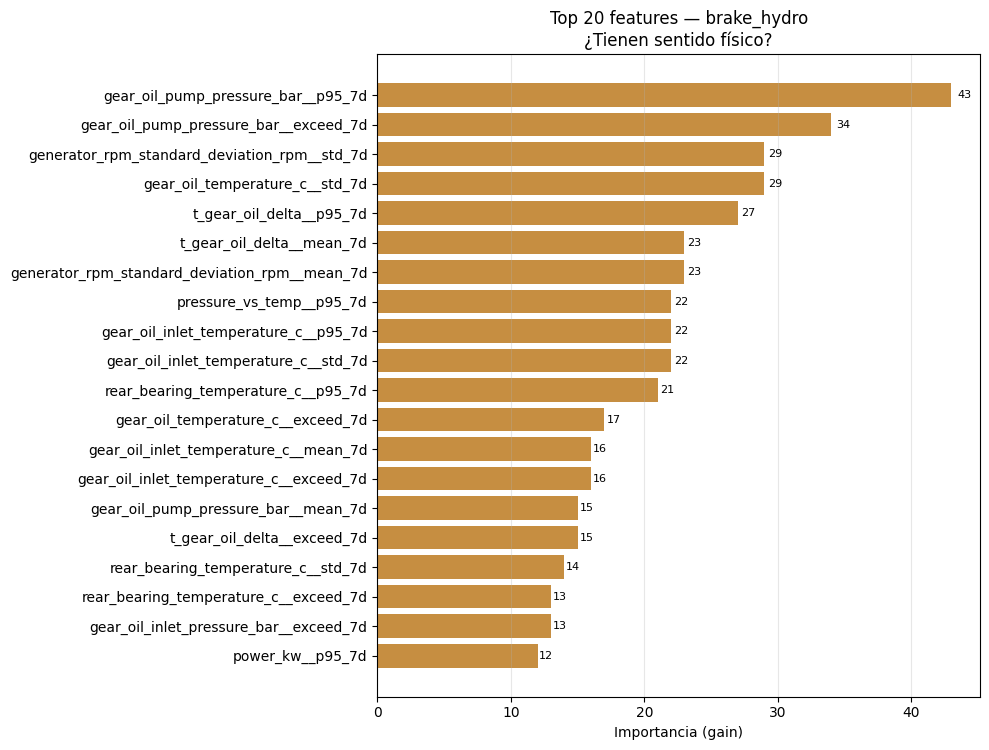

  Guardado: feature_importance_brake_hydro.png


In [13]:
plot_feature_importance(model, feature_cols, family, '#BA7517')


## 6. Curva Precision-Recall

La curva Precision-Recall permite elegir el threshold según el coste operativo:

- **Threshold bajo** (ej: 0.10): más fallos detectados (Recall alto), más falsas alarmas
- **Threshold alto** (ej: 0.50): menos falsas alarmas (Precision alta), más fallos perdidos

El threshold elegido automáticamente es el menor valor que mantiene Precision ≥ 10% en la evaluación por fila.

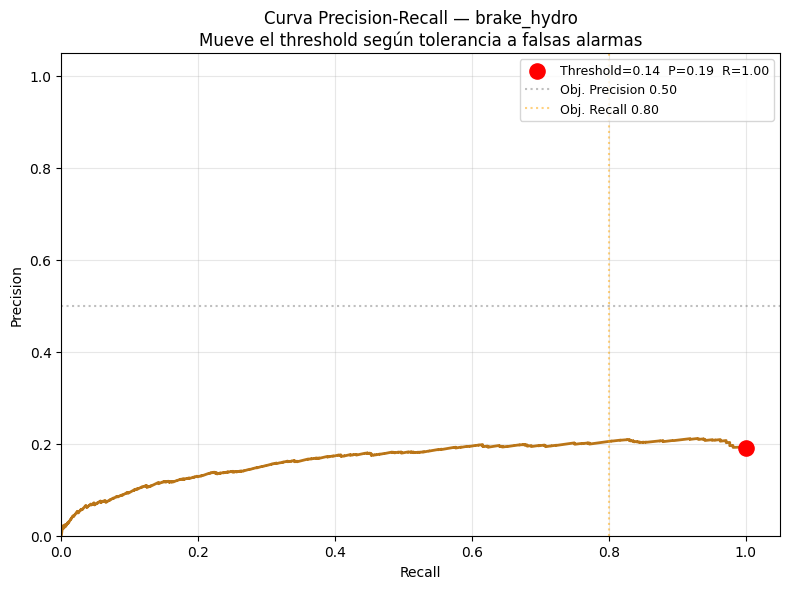

In [14]:
plot_pr_curve(pr_data, family, metrics['threshold'], '#BA7517')


## 7. Timeline de Alertas vs Fallos Reales

Visualización del período de test completo:

- La curva muestra la probabilidad predicha de fallo en cada intervalo de 10 minutos
- Las líneas **verdes** marcan fallos que recibieron al menos una alerta antes
- Las líneas **rojas** marcan fallos que no fueron detectados
- La línea punteada roja es el threshold de clasificación

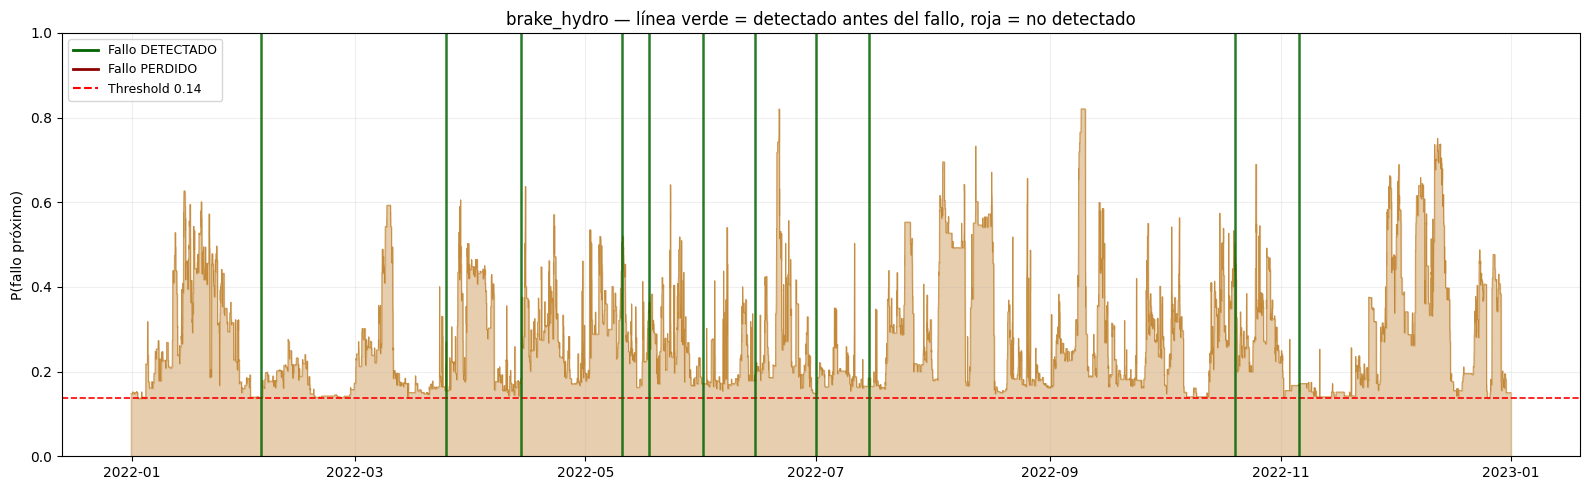

  Guardado: timeline_brake_hydro.png


In [15]:
plot_alert_timeline(test_df, y_prob, family, metrics['threshold'], ev_details, '#BA7517')


## 8. Resumen de Resultados

In [16]:
print('=' * 55)
print(f'RESULTADOS — brake_hydro')
print('=' * 55)
print(f'  AUC-ROC:          {metrics["auc_roc"]:.3f}')
print(f'  Precision (fila): {metrics["precision_row"]:.3f}')
print(f'  Recall    (fila): {metrics["recall_row"]:.3f}')
print(f'  F1        (fila): {metrics["f1_row"]:.3f}')
print()
print(f'  Event Recall:     {metrics["event_recall"]:.3f}  (← métrica principal)')
print(f'  Fallos detectados:{metrics["events_detected"]} / {metrics["events_total"]}')
print()
ok = '✅' if metrics['event_recall'] >= 0.80 else ('⚠️' if metrics['event_recall'] >= 0.50 else '❌')
print(f'  Objetivo Event Recall > 0.80: {ok}')
print()
print('Detalles por evento:')
for det in ev_details:
    status = '✅ detectado' if det['detected'] else '❌ perdido'
    print(f"  {det['fault_start'].date()}  max_prob={det['max_prob']:.3f}  {status}")


RESULTADOS — brake_hydro
  AUC-ROC:          0.481
  Precision (fila): 0.189
  Recall    (fila): 1.000
  F1        (fila): 0.318

  Event Recall:     1.000  (← métrica principal)
  Fallos detectados:11 / 11

  Objetivo Event Recall > 0.80: ✅

Detalles por evento:
  2022-02-04  max_prob=0.204  ✅ detectado
  2022-03-25  max_prob=0.606  ✅ detectado
  2022-04-13  max_prob=0.637  ✅ detectado
  2022-05-10  max_prob=0.520  ✅ detectado
  2022-05-17  max_prob=0.423  ✅ detectado
  2022-06-01  max_prob=0.415  ✅ detectado
  2022-06-14  max_prob=0.425  ✅ detectado
  2022-07-01  max_prob=0.350  ✅ detectado
  2022-07-15  max_prob=0.371  ✅ detectado
  2022-10-19  max_prob=0.455  ✅ detectado
  2022-11-05  max_prob=0.175  ✅ detectado


---

## 📋 Conclusiones

Los resultados se guardan en `data/models/` como:
- `model_brake_hydro.pkl` — modelo serializado para inferencia
- `results_brake_hydro.json` — métricas completas del entrenamiento

Para usar el modelo en producción:
1. Calcular las features rolling sobre los últimos 7 días de telemetría
2. Llamar a `model.predict_proba(X)[:, 1]`
3. Si el resultado supera `threshold óptimo calculado automáticamente por familia`, emitir alerta
